## EDA and Data Cleaning

### Import Python Libraries and set properties for the notebook

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
import gc

In [80]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
# Force pandas to display 2 decimal places (no scientific notation)
pd.options.display.float_format = '{:.2f}'.format

### Import data from the raw file

In [81]:
#filepath = '../data/raw/neiss_combined_raw_untouched_data.csv'
#data_original = pd.read_csv(filepath, engine='pyarrow')
filepath = '../data/raw/neiss_original_raw_untouched_data.parquet'
data_original = pd.read_parquet(filepath)

In [82]:
# Deep copy to preserve original data
data = data_original.copy()

In [83]:
data.columns

Index(['data_year', 'CPSC_Case_Number', 'Treatment_Date', 'Age', 'Sex', 'Race',
       'Other_Race', 'Hispanic', 'Body_Part', 'Diagnosis', 'Other_Diagnosis',
       'Body_Part_2', 'Diagnosis_2', 'Other_Diagnosis_2', 'Disposition',
       'Location', 'Fire_Involvement', 'Product_1', 'Product_2', 'Product_3',
       'Alcohol', 'Drug', 'Narrative_1', 'Stratum', 'PSU', 'Weight'],
      dtype='str')

In [84]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 26 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                int64         
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          int64         
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       
 

### Trend Analysis - Timeseries (Weighted)

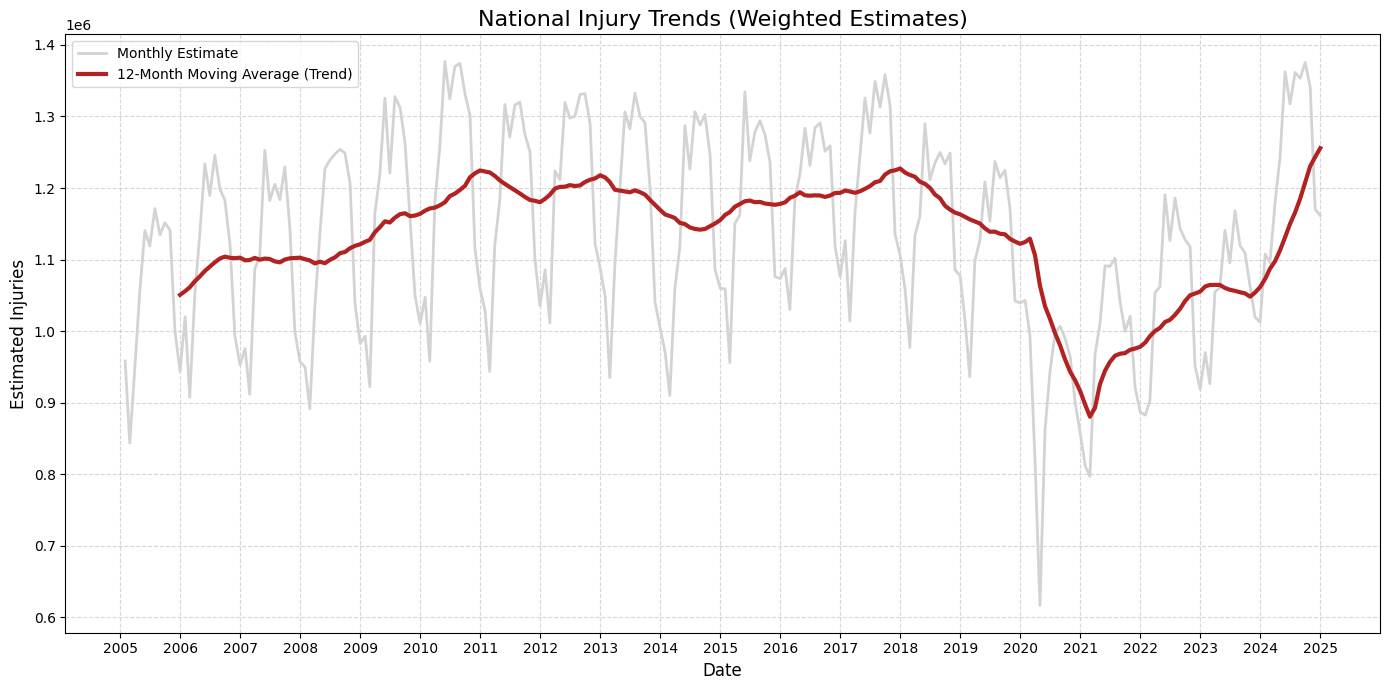

/var/folders/ln/zf609vjj3z1_h7nn_glp_bpc0000gn/T/ipykernel_28998/788691604.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=monthly_injuries, x='Month_Name', y='Estimated_Injuries',


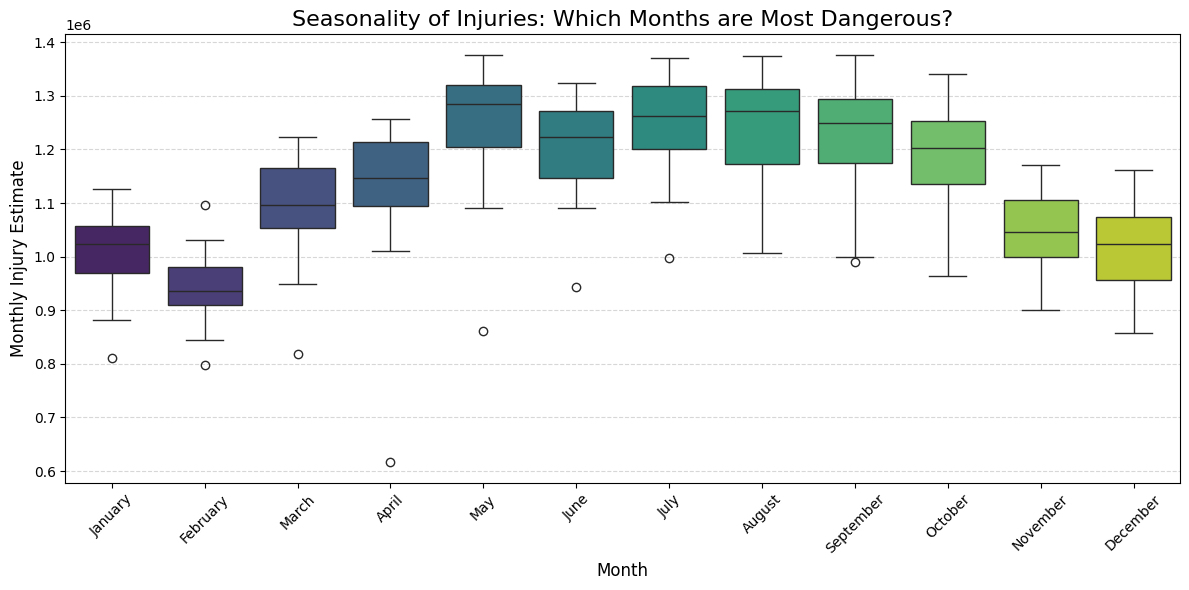


--- Time Series Summary ---
Peak Injury Month: May 2010 (1,376,782 estimated injuries)
Average Monthly Injuries: 1,131,957


In [85]:
df = data.copy()
# --- DATA PREPARATION ---
# Ensure dates are datetime objects
df['Treatment_Date'] = pd.to_datetime(df['Treatment_Date'])

# Set the date as the index (Required for time-series resampling)
df.set_index('Treatment_Date', inplace=True)

# --AGGREGATION (THE CRITICAL STEP) ---
# Resample by 'M' (Month) and Sum the 'Weight'
# This gives us the Total Estimated Injuries per Month
monthly_injuries = df['Weight'].resample('ME').sum().to_frame(name='Estimated_Injuries')

# Calculate a 12-Month Rolling Average (Trend Line)
# This smooths out the jagged peaks to show if injuries are actually rising/falling
monthly_injuries['Trend_12M'] = monthly_injuries['Estimated_Injuries'].rolling(window=12).mean()

# --- VISUALIZATION 1: LONG-TERM TREND ---
plt.figure(figsize=(14, 7))

# Plot Raw Monthly Data
plt.plot(monthly_injuries.index, monthly_injuries['Estimated_Injuries'], 
         label='Monthly Estimate', color='lightgray', linewidth=2)

# Plot Trend Line (Rolling Mean)
plt.plot(monthly_injuries.index, monthly_injuries['Trend_12M'], 
         label='12-Month Moving Average (Trend)', color='firebrick', linewidth=3)

plt.title('National Injury Trends (Weighted Estimates)', fontsize=16)
plt.ylabel('Estimated Injuries', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Format X-Axis to show years clearly
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# --- VISUALIZATION 2: SEASONALITY ANALYSIS ---
# Extract Month Name for grouping
monthly_injuries['Month_Name'] = monthly_injuries.index.month_name()
# Sort order for the plot
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 6))

# Boxplot shows the distribution of injury counts for each month across all years
sns.boxplot(data=monthly_injuries, x='Month_Name', y='Estimated_Injuries', 
            order=month_order, palette='viridis')

plt.title('Seasonality of Injuries: Which Months are Most Dangerous?', fontsize=16)
plt.ylabel('Monthly Injury Estimate', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# ---  STATISTICAL SUMMARY ---
print("\n--- Time Series Summary ---")
peak_month = monthly_injuries['Estimated_Injuries'].idxmax()
peak_value = monthly_injuries['Estimated_Injuries'].max()
print(f"Peak Injury Month: {peak_month.strftime('%B %Y')} ({int(peak_value):,} estimated injuries)")

avg_monthly = monthly_injuries['Estimated_Injuries'].mean()
print(f"Average Monthly Injuries: {int(avg_monthly):,}")

### Summary of Columns with NULL, Unknown and their Percentages

In [86]:
# 1. Define the specific "Missing Value" codes for NEISS dataset
neiss_missing_codes = {
    'Race': [0],
    'Sex': [0],
    'Location': [0],
    'Fire_Involvement': [0],
    'Disposition': [9]
}

def check_missing_data(df, specific_codes):
    report = []
    
    for col in df.columns:
        # 1. Count actual Nulls (NaN)
        null_count = df[col].isnull().sum()
        total_rows = len(df)
        null_percent = (null_count / total_rows) * 100
        
        # 2. Count "Code 0" (if applicable to this column)
        missing_data_count = 0
        if col in specific_codes:
            # Counts how many times the specific code (like 0) appears
            missing_data_count = df[col].isin(specific_codes[col]).sum()
            
        # 3. Calculate Totals
        total_missing = null_count + missing_data_count
        percent_missing = (total_missing / total_rows) * 100
        
        report.append({
            'Column Name': col,
            'Null Count': null_count,
            'Null %': round(null_percent, 2),
            'Unknown Count': missing_data_count,
            'Total_Missing(Null & Unknown)': total_missing,
            'Percentage Missing': round(percent_missing, 2)
        })
        
    return pd.DataFrame(report).sort_values('Percentage Missing', ascending=False)

# Run the check
missing_report = check_missing_data(data, neiss_missing_codes)
pd.DataFrame(missing_report)

,Column Name,Null Count,Null %,Unknown Count,Total_Missing(Null & Unknown),Percentage Missing
16,Fire_Involvement,0,0.00,7283693,7283693,99.56
13,Other_Diagnosis_2,7214095,98.61,0,7214095,98.61
12,Diagnosis_2,6866693,93.86,0,6866693,93.86
11,Body_Part_2,6866693,93.86,0,6866693,93.86
6,Other_Race,6821041,93.24,0,6821041,93.24
10,Other_Diagnosis,6329255,86.52,0,6329255,86.52
20,Alcohol,5283928,72.23,0,5283928,72.23
21,Drug,5283928,72.23,0,5283928,72.23
7,Hispanic,5283928,72.23,0,5283928,72.23
5,Race,0,0.00,2145028,2145028,29.32


### 1. Handling NULL Data in the file <br>

In [87]:
null_data = data.isnull().sum().reset_index()
null_data.columns = ['Column_Name', 'Count']
null_data = null_data[null_data['Count'] > 0]
null_data

,Column_Name,Count
6,Other_Race,6821041
7,Hispanic,5283928
10,Other_Diagnosis,6329255
11,Body_Part_2,6866693
12,Diagnosis_2,6866693
13,Other_Diagnosis_2,7214095
20,Alcohol,5283928
21,Drug,5283928


#### The above list of features have null values that needs to be handled. <br>


#### 1.1 NULL Values in Other_Race Feature
Other Race feature is a string field which lists the description of other race if the race used in the Race field is 3. Hence, update the Other_Race with a NULL value as "UNKNOWN"

In [88]:
print(f'Null values in Other_Race Feature before change:{data["Other_Race"].isnull().sum()}') 
data['Other_Race'] = data['Other_Race'].fillna('OTHER')
print(f'Null values in Other_Race Feature after change:{data["Other_Race"].isnull().sum()}') 

Null values in Other_Race Feature before change:6821041
Null values in Other_Race Feature after change:0


#### 1.2. Handle NULL values in Hispanic Feature

Fill the NULL records with 0.0 - Unknown.

In [89]:
print(data.Hispanic.value_counts())
print(f'Null values in Hispanic Feature before change:{data["Hispanic"].isnull().sum()}') 
data['Hispanic'] = data['Hispanic'].fillna('0.0')
data['Hispanic'] = data['Hispanic'].astype(float)
print(f'Null values in Hispanic Feature after change:{data["Hispanic"].isnull().sum()}')
print(data.Hispanic.value_counts())

Hispanic
2.00    1231235
0.00     586760
1.00     213809
Name: count, dtype: int64
Null values in Hispanic Feature before change:5283928
Null values in Hispanic Feature after change:0
Hispanic
0.00    5870688
2.00    1231235
1.00     213809
Name: count, dtype: int64


#### 1.3 Handle NULL values in Other_Diagnosis Feature

In [90]:
print(f'Null values in Other_Diagnosis Feature before change:{data["Other_Diagnosis"].isnull().sum()}') 
data['Other_Diagnosis'] = data['Other_Diagnosis'].fillna('UNKNOWN')
print(f'Null values in Other_Diagnosis Feature after change:{data["Other_Diagnosis"].isnull().sum()}') 

Null values in Other_Diagnosis Feature before change:6329255
Null values in Other_Diagnosis Feature after change:0


#### 1.4. Handle NULL values in Body_Part_2 Feature

In [91]:
print(f'Null values in Body_Part_2 Feature before change:{data["Body_Part_2"].isnull().sum()}') 
data['Body_Part_2'] = data['Body_Part_2'].fillna(87.0)
data['Body_Part_2'] = data['Body_Part_2'].astype(float)
print(f'Null values in Body_Part_2 Feature after change:{data["Body_Part_2"].isnull().sum()}') 

Null values in Body_Part_2 Feature before change:6866693
Null values in Body_Part_2 Feature after change:0


#### 1.5. Handle NULL values in Diagnosis_2 Feature

In [92]:
print(f'Null values in Diagnosis_2 Feature before change:{data["Diagnosis_2"].isnull().sum()}') 
data['Diagnosis_2'] = data['Diagnosis_2'].fillna(71.0)
print(f'Null values in Diagnosis_2 Feature after change:{data["Diagnosis_2"].isnull().sum()}')

Null values in Diagnosis_2 Feature before change:6866693
Null values in Diagnosis_2 Feature after change:0


#### 1.6. Handle NULL values in Other_Diagnosis_2 Feature

In [93]:
print(f'Null values in Other_Diagnosis_2 Feature before change:{data["Other_Diagnosis_2"].isnull().sum()}') 
data['Other_Diagnosis_2'] = data['Other_Diagnosis_2'].fillna('UNKNOWN')
print(f'Null values in Other_Diagnosis_2 Feature after change:{data["Other_Diagnosis_2"].isnull().sum()}') 

Null values in Other_Diagnosis_2 Feature before change:7214095
Null values in Other_Diagnosis_2 Feature after change:0


#### 1.7. Handle NULL values in the Alcohol Feature 

In [94]:
print(f'Null values in Alcohol Feature before change:{data["Alcohol"].isnull().sum()}') 
data['Alcohol'] = data['Alcohol'].fillna(3)
print(f'Null values in Alcohol Feature after change:{data["Alcohol"].isnull().sum()}') 
print(data['Alcohol'].value_counts())

Null values in Alcohol Feature before change:5283928
Null values in Alcohol Feature after change:0
Alcohol
3.00    5283928
0.00    1993098
1.00      38706
Name: count, dtype: int64


#### 1.8. Null values in the Drug Feature 

In [95]:
print(f'Null values in Drug Feature before change:{data["Drug"].isnull().sum()}') 
data['Drug'] = data['Drug'].fillna(3)
print(f'Null values in Alcohol Feature after change:{data["Drug"].isnull().sum()}') 
print(data['Drug'].value_counts())

Null values in Drug Feature before change:5283928
Null values in Alcohol Feature after change:0
Drug
3.00    5283928
0.00    1986756
1.00      45048
Name: count, dtype: int64


#### Validate if all the null values are fixed

In [96]:
missing_report = check_missing_data(data, neiss_missing_codes)
missing_report_df = pd.DataFrame(missing_report)
missing_report_df[missing_report_df['Null Count'] > 0]

,Column Name,Null Count,Null %,Unknown Count,Total_Missing(Null & Unknown),Percentage Missing


No null values exist in the data.

### 2. Handle Unknown Values (If Needed)

In [97]:
missing_report_df[missing_report_df['Total_Missing(Null & Unknown)'] > 0]
#missing_report_df[['Column Name','Total_Missing(Null & Unknown)','Percentage Missing']]

,Column Name,Null Count,Null %,Unknown Count,Total_Missing(Null & Unknown),Percentage Missing
16,Fire_Involvement,0,0.00,7283693,7283693,99.56
5,Race,0,0.00,2145028,2145028,29.32
15,Location,0,0.00,2099509,2099509,28.70
14,Disposition,0,0.00,382,382,0.01
4,Sex,0,0.00,978,978,0.01


#### 2.1 Handle unknown values in Fire_Involvement Feature

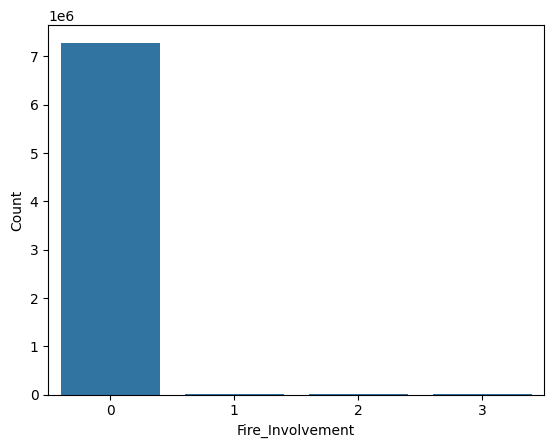

In [98]:
unknown_fire = data.Fire_Involvement.value_counts().reset_index()
unknown_fire.columns = ['Fire_Involvement', 'Count']
sns.barplot(data=unknown_fire, x='Fire_Involvement', y='Count')
plt.show()

As more than 99% of the entries does not have a fire attribute, we will treat this as a category and will not substitute.

#### 2.2 Handle unknown values in Race Feature

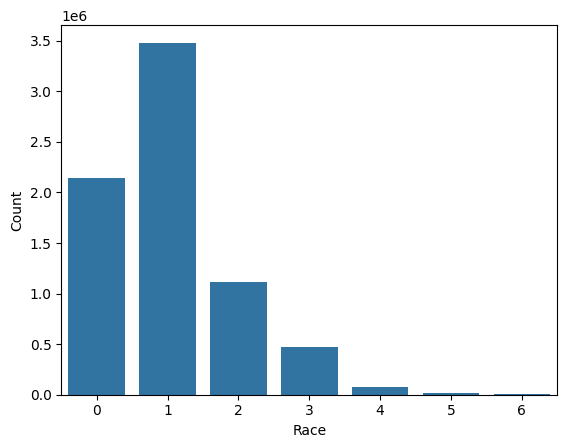

In [99]:
unknown_race = data.Race.value_counts().reset_index()
unknown_race.columns = ['Race', 'Count']
sns.barplot(data=unknown_race, x='Race', y='Count')
plt.show()

As more than 29% of records does not have race - we will treat this as a category and will not substitute.

#### 2.3 Handle unknown values in Location Feature

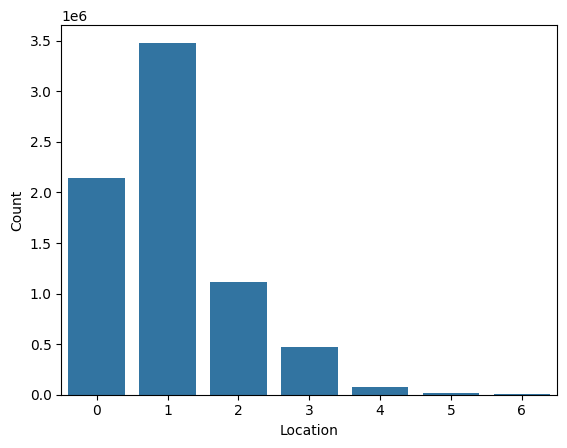

In [100]:
unknown_location = data.Race.value_counts().reset_index()
unknown_location.columns = ['Location', 'Count']
sns.barplot(data=unknown_location, x='Location', y='Count')
plt.show()

As more than 28% of records does not have a location - we will treat this as a category and will not substitute.

#### 2.4 Handle unknown values in Disposition Feature

Roughly 382 records does not have a disposition - we need to know the disposition to decide if a patient was hospitalized or not.  we have two options. <br>
1. Drop these records as the count is <1% <br>
2. Classify these records as 'Not Hospitalized' when we perfrom the feature engineering.

We will choose **#2** at this juncture.

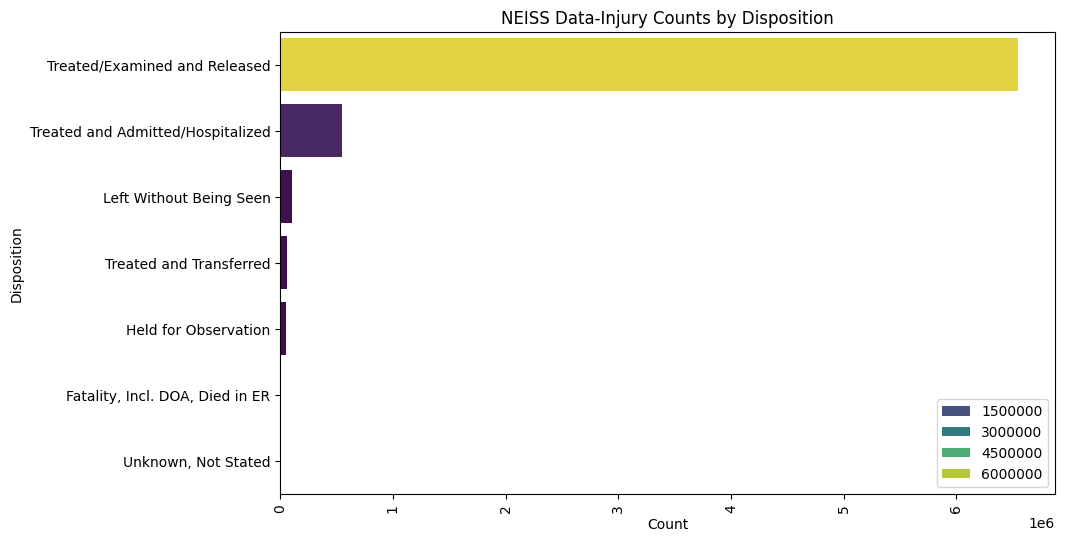

In [101]:

top10_injury_count_by_disposition = data.Disposition.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_disposition.columns = ['Disposition', 'Count']
disposition_map = {
    1: 'Treated/Examined and Released',
    2: 'Treated and Transferred',
    4: 'Treated and Admitted/Hospitalized',
    5: 'Held for Observation',
    6: 'Left Without Being Seen',
    8: 'Fatality, Incl. DOA, Died in ER',
    9: 'Unknown, Not Stated'
}
top10_injury_count_by_disposition['Disposition'] = top10_injury_count_by_disposition['Disposition'].map(disposition_map)
sort_order = top10_injury_count_by_disposition['Disposition'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Disposition', data=top10_injury_count_by_disposition, hue='Count', dodge=False, palette='viridis', order=sort_order)
plt.title('NEISS Data-Injury Counts by Disposition')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.legend(loc='lower right')
plt.show()

90% of all the Injuries were trearted/examined and released.<br>
7.5% of the Injuries were Admitted/Hospitalized.<br>
Based on the disposition, we need to create a new feature 'Hospitalized' that groups the dispositions. <br>

#### 2.5 Handle unknown values in Sex Feature

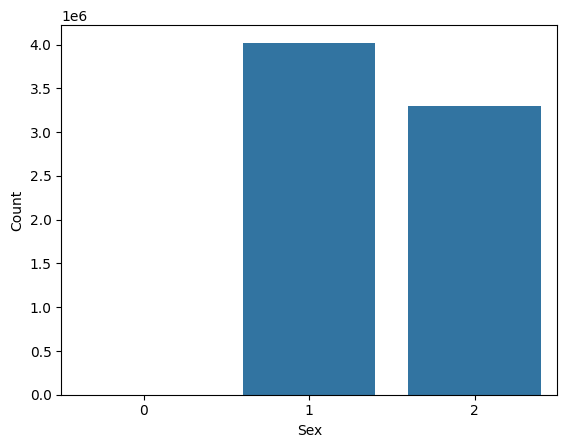

In [102]:
unknown_sex = data.Sex.value_counts().reset_index()
unknown_sex.columns = ['Sex', 'Count']
sns.barplot(data=unknown_sex, x='Sex', y='Count')
plt.show()

Less than 1% of the values does not have a Sex. We can substitute these records with the common Sex value.

In [103]:
data['Sex'] = data.Sex.replace({0:1})
data.Sex.value_counts().reset_index()

,Sex,count
0,1,4022516
1,2,3293216


#### Check if we handled all the unknown records

In [104]:
missing_report = check_missing_data(data, neiss_missing_codes)
missing_report_df = pd.DataFrame(missing_report)
missing_report_df[missing_report_df['Total_Missing(Null & Unknown)'] > 0]
#missing_report_df[['Column Name','Total_Missing(Null & Unknown)','Percentage Missing']]

,Column Name,Null Count,Null %,Unknown Count,Total_Missing(Null & Unknown),Percentage Missing
16,Fire_Involvement,0,0.00,7283693,7283693,99.56
5,Race,0,0.00,2145028,2145028,29.32
15,Location,0,0.00,2099509,2099509,28.70
14,Disposition,0,0.00,382,382,0.01


### 3. Finding Outliers

#### 3.1 Categorical Variables 

In [105]:
# 1. Finding Categorical Outliers (Ultra-Rare Products)
product_counts_1 = data['Product_1'].value_counts()
rare_products_1 = product_counts_1[product_counts_1 < 10] # Products with fewer than 10 injuries
print(f"Found {len(rare_products_1)} categorical outliers (rare products-1).")

# 2. Finding Text Outliers (Suspiciously short narratives)
data['Narrative_Length'] = data['Narrative_1'].astype(str).apply(len)
short_text_outliers = data[data['Narrative_Length'] < 10]
print(f"Found {len(short_text_outliers)} text outliers (narratives under 10 characters).")

# 3. Finding Categorical Outliers (Ultra-Rare Products)
product_counts_2 = data['Product_2'].value_counts()
rare_products_2 = product_counts_2[product_counts_2 < 100] # Products with fewer than 10 injuries
print(f"Found {len(rare_products_2)} categorical outliers (rare products-2).")

# 4. Finding Categorical Outliers (Ultra-Rare Products)
product_counts_3 = data['Product_3'].value_counts()
rare_products_3 = product_counts_3[product_counts_3 < 10] # Products with fewer than 10 injuries
print(f"Found {len(rare_products_3)} categorical outliers (rare products-3).")

Found 18 categorical outliers (rare products-1).
Found 10 text outliers (narratives under 10 characters).
Found 391 categorical outliers (rare products-2).
Found 341 categorical outliers (rare products-3).


### 4. Check for Duplicates

In [106]:
duplicated_rows = data[data.duplicated()].shape[0]
print("duplicated_rows:", duplicated_rows)

duplicated_rows: 0


No need to remove duplicate records as the data doesnt have any duplicates

### 5. EDA and Data Cleaning

#### 5.1 Handle Age Feature <br>
Perfrom conversion of age in months to years and decide if we need to handle "Age not recorded" 0 Age.

According to the data dictionary, the age is 0 if not recorded, it is 2 and 120 in years or it is recorded in months 0f 201 - 223 for age < 2 years.

We need to make Age into a uniform scale of years. To do this, we will convert the age < 2 years.

In [107]:
def convert_age(age):
    if age >200:
        new_age = (age-200)/12 
    else:
        new_age = age 
    return new_age
data['Age'] = data['Age'].apply(convert_age)

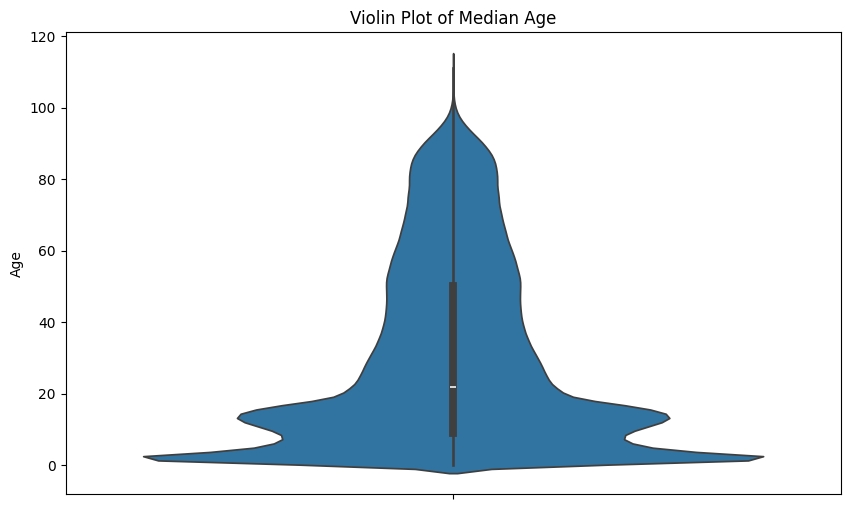

In [108]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=data, y="Age")
plt.title("Violin Plot of Median Age")
plt.show()


Check how many records has zero age and decide how to handle the records with missing age.

In [109]:
zero_age_count = data[data[['Age']].Age == 0].shape
print(f'Count of records with zero age:{zero_age_count[0]}')
median_age = data['Age'].median().round(2)
print(f'Median Age:{median_age}')

Count of records with zero age:504
Median Age:22.0


As the count of records with age =0 is around 500 we can either drop them or can fill it with the median age.
We will do this step during the Feature engineering as doing it here could lead to data leakage.

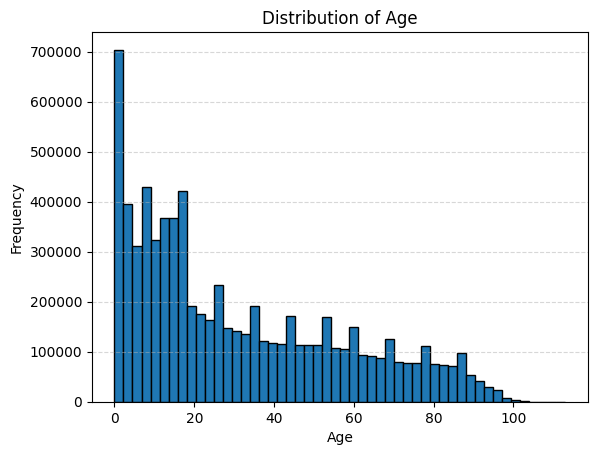

In [110]:
data[['Age']].Age.plot(kind='hist', bins=50, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 5.2 Consistancy Evaluation and handling inconsistant Records

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def evaluate_consistency(df):
    print("--- NEISS CONSISTENCY EVALUATION REPORT ---")
    
    # 1. TEMPORAL CONSISTENCY CHECK
    # Check for sudden "death" of a product code (indicates re-classification)
    # Group by Year and Product, count occurrences
    if 'Treatment_Date' in df.columns:
        df['Year'] = pd.to_datetime(df['Treatment_Date']).dt.year
        yearly_counts = df.groupby(['Year', 'Product_1']).size().unstack(fill_value=0)
        
        # Flag products that have 0 counts in some years but >100 in others
        inconsistent_codes = []
        for product in yearly_counts.columns:
            counts = yearly_counts[product]
            if (counts.min() == 0) and (counts.max() > 50):
                inconsistent_codes.append(product)
        
        print(f"\n[Temporal] {len(inconsistent_codes)} Products show inconsistent reporting (zeros in some years).")
        print(f"Sample inconsistent codes: {inconsistent_codes[:50]}")
    
    # 2. INTERNAL LOGIC CHECK (Age vs. Product)
    # Define "Adult" products that shouldn't appear for toddlers (Age < 2 years / Code > 200)
    # Example: Chainsaws (1411), Lawn Mowers (1401)
    adult_products = [1411, 1401, 1916] # Chainsaws, Mowers, Alcohol
    
    # Filter for "Infants" (Age < 4 years or Code 200-224)
    # Note: NEISS Age < 2 is coded as 200 + months.
    infant_mask = (df['Age'] < 4) | ((df['Age'] >= 200) & (df['Age'] <= 224))
    
    suspicious_cases = df[infant_mask & df['Product_1'].isin(adult_products)]
    
    print(f"\n[Internal Logic] Found {len(suspicious_cases)} suspicious cases of Infants using Adult Products.")
    if not suspicious_cases.empty:
        print(suspicious_cases[['Age', 'Product_1', 'Narrative_1']].head())

    # 3. BODY PART vs DIAGNOSIS CONSISTENCY
    # Check for "Concussion" (52) on Body Parts other than "Head" (75)
    concussion_errors = df[(df['Diagnosis'] == 52) & (df['Body_Part'] != 75)]
    
    print(f"\n[Medical Logic] Found {len(concussion_errors)} Concussions listed for non-Head body parts.")
    print(f"Error Rate: {len(concussion_errors) / len(df) * 100:.4f}%")

    return inconsistent_codes, suspicious_cases, concussion_errors

inconsistent_codes, suspicious_cases, concussion_errors = evaluate_consistency(data)

--- NEISS CONSISTENCY EVALUATION REPORT ---

[Temporal] 47 Products show inconsistent reporting (zeros in some years).
Sample inconsistent codes: [394, 556, 569, 574, 876, 897, 899, 1132, 1145, 1317, 1329, 1381, 1394, 1395, 1417, 1465, 1466, 1527, 1543, 1545, 1552, 1606, 1618, 1620, 1629, 1706, 1707, 1710, 1841, 1855, 1909, 3215, 4802, 5004, 5016, 5017, 5019, 5020, 5021, 5022, 5023, 5024, 5025, 5042, 5043, 5045, 5046]

[Internal Logic] Found 776 suspicious cases of Infants using Adult Products.
       Age  Product_1                                        Narrative_1
7152  2.00       1401  PT TOUCHED A HOT LAWN MOWER MUFFLER WITH LOWER...
8969  3.00       1916                   TOOK 100 *** VITAMINES WITH IRON
9061  3.00       1916  PT INGESTED ***, PRENATAL VITAMINS WITH IRON, ...
11774 3.00       1916  ATE 1/ BOTTLE CHILDREN'S VITAMINS W/IRON DX: A...
33564 1.08       1916  ACCIDENTAL VITAMIN ING/13MOF BETWEEN 10 & NOON...

[Medical Logic] Found 0 Concussions listed for non-Head body 

#### Harmonizing Taxonomy Changes in the Product ID classification

In [112]:
crosswalk = {
        # --- 1. TELEVISIONS (Consolidated to 5016) ---
        574: 5016,   # Old: Console TVs -> New: Televisions
        514:569,
        564:569,
        876:897,
        865:897,
        873:897,
        897: 5016,   # Old: Non-console TVs -> New: Televisions
        899: 5016,   # Old: TVs, not specified -> New: Televisions
        1132:5021,
        1332:5021,
        1383:5021,
        1306:5021,
        1317:5021,
        1318:5021,
        1356:5021,
        5004:5021,
        1855:1145,
        1329:5023,
        1417:"Decorative Yard Equipment",
        1465:"Decorative Yard Equipment",
        1466:"Decorative Yard Equipment",
        # --- 2. CRIBS (Consolidated in 2021) ---
        1543: 1552,  # Old: Cribs, nonportable -> New: Cribs (nonportable/unspecified)
        1545: 1552,  # Old: Cribs, not specified -> New: Cribs (nonportable/unspecified)
        # --- 3. TOYS (Major redesign in 2010) ---
        # 5004 was the old catch-all for "Toys, not elsewhere classified". 
        # It was retired and replaced by 1381 and 1395. We map the old one to 1395.
        5004: 1395,  # Old: Toys (NEC) -> New: Toys, not specified

        # --- 4. BABY CARRIERS (Redesigned in 2019) ---
        # 1527 was retired and split into 3 codes (1560 Slings, 1561 Framed, 1562 Unframed).
        # We map it to a custom string bin to preserve all baby carrier data.
        1527: 'Baby Carriers (All)', 

        # --- 5. E-BIKES & MOPEDS (Redesigned in 2024) ---
        # 3215 was retired and split into 5045 (E-Bikes) and 5046 (Other).
        3215: 5046,  # Old: Mopeds/power-assisted -> New: Other power-assisted cycles
        
        # --- 6. MICROMOBILITY & SCOOTERS (Redesigned in 2020) ---
        # 1329 was replaced directly by 5023.
        # 5042 was a messy bucket split into 5022 (E-Scooters) and 5025 (Hoverboards).
        1329: 5023,  # Old: Unpowered scooters -> New: Scooters, unpowered
        5042: 5022,  # Old: Powered scooters (mapped to modern E-scooter code)

        # =========================================================
        # OPTIONAL: "BINNING" FOR HIGHLY FRAGMENTED MODERN CODES
        # If you leave these as separate codes, your algorithm might struggle 
        # because the data is spread too thin. You can bin them into strings:
        # =========================================================
        
        # Binning the ATVs / UTVs
        5017: 'Off-Road Vehicles (ATV/UTV)', # ATV, 4 wheels
        5019: 'Off-Road Vehicles (ATV/UTV)', # ATV, unspecified
        5020: 'Off-Road Vehicles (ATV/UTV)', # ATV, >4 wheels
        5021: 'Off-Road Vehicles (ATV/UTV)', # UTVs
        5043: 'Off-Road Vehicles (ATV/UTV)', # Portable/Recreational utility vehicles

        # Binning the new Micromobility codes into one master category
        5022: 'Micromobility (Scooters/Hoverboards)', # E-Scooters
        5023: 'Micromobility (Scooters/Hoverboards)', # Unpowered Scooters
        5024: 'Micromobility (Scooters/Hoverboards)', # Unspecified Scooters
        5025: 'Micromobility (Scooters/Hoverboards)', # Hoverboards
        
        # Binning the E-bikes
        5045: 'Power-Assisted Cycles (E-bikes)',
        5046: 'Power-Assisted Cycles (E-bikes)'
    }

# Convert the product_1 column to string to accommodate both numeric and string codes after replacement
data['Product_1'] = data['Product_1'].astype(str)
# Apply the crosswalk dictionary
data['Product_1'] = data['Product_1'].replace(crosswalk)

#### Remove inconsistant injury cases

In [113]:
print(f'Count of records in Original Dataset: {data.shape[0]}')
print(f'Count of suspicious cases: {len(suspicious_cases)}')
# Remove cases with suspicious age-product combinations (Infants with Adult products)
data_cleaned = data[~data.index.isin(suspicious_cases.index)]   
print(f'Count of records in Cleaned Dataset: {data_cleaned.shape[0]}')
# Percentage change after removing suspicious cases
percent_change = ((data.shape[0] - data_cleaned.shape[0]) / data.shape[0]) * 100
print(f'Percentage change after removing suspicious cases: {percent_change:.4f}%')

Count of records in Original Dataset: 7315732
Count of suspicious cases: 776
Count of records in Cleaned Dataset: 7314956
Percentage change after removing suspicious cases: 0.0106%


### 5.3 Should we remove records with no diagnosis?


The record selection dictates which rows from the initial dataset makes to the final dataset.  We undertake a Quality based Exclusion whereby we drop records with diagnosis 71 (Other/not stated) as it is not useful for understanding the disposition of the patient. 

In [114]:
no_diagnosis = data_cleaned[data_cleaned['Diagnosis'] == 71]
print(f'Count of records with Diagnosis code 71 (Other/Not Stated): {no_diagnosis.shape[0]}')

# Count of records before removing Diagnosis code 71
print(f'Count of records before removing Diagnosis code 71: {data_cleaned.shape[0]}')

# Percentage of records with Diagnosis code 71
percent_no_diagnosis = (no_diagnosis.shape[0] / data_cleaned.shape[0]) * 100
print(f'Percentage of records with Diagnosis code 71: {percent_no_diagnosis:.2f}%')

Count of records with Diagnosis code 71 (Other/Not Stated): 987216
Count of records before removing Diagnosis code 71: 7314956
Percentage of records with Diagnosis code 71: 13.50%


#### Analysis revealed that 13.5% of the dataset (n=987,216) utilized the Diagnosis code 71 ('Other/Not Stated'). To preserve statistical power and prevent Missing Not At Random (MNAR) bias, these records were not excised. Instead, 'Unspecified' was retained as an explicit categorical feature, ensuring the model could learn potential correlations between vague diagnostic coding and patient disposition."

### 6. Remove temporaray columns

In [115]:
data_cleaned = data_cleaned.drop(columns = ['Narrative_Length','Year'])

### 6. Save the data to the interim folder for future use

In [116]:
#data.to_csv('../data/interim/neiss_interim_data.csv', index=False)
data_cleaned.to_parquet('../data/interim/neiss_interim_data.parquet')
#n = gc.collect()
#print(f"Number of unreachable objects collected: {n}")